# Lines

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skimage.io as io
import skimage.draw as draw
from skimage.feature import canny
from skimage.transform import hough_line, hough_line_peaks
from skimage.color import rgb2gray

plt.style.use('../_static/bip.mplstyle')
plt.rcParams['image.cmap'] = 'gray'

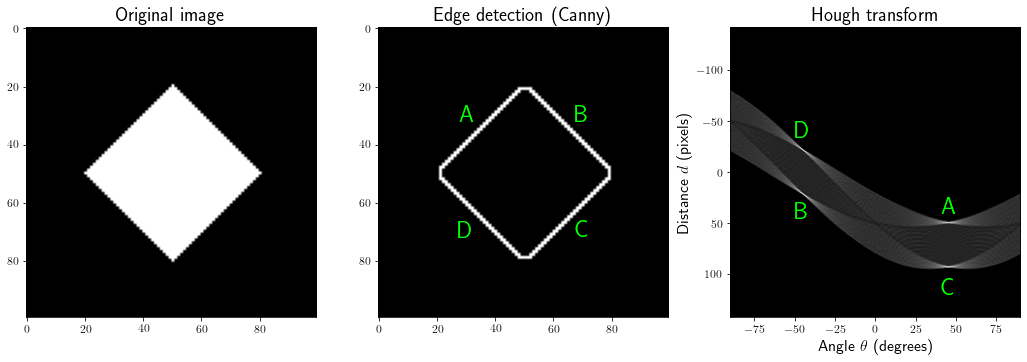

In [2]:
# Display
clr = 'lime'
fs = 24
fig, axs = plt.subplots(1, 3, figsize=(15,5))
fig.tight_layout(pad=1.5)

# Image
N = 100
img = np.zeros((N,N))
r = np.round(np.array([.5, .8, .5, .2])*N)
c = np.round(np.array([.2, .5, .8, .5])*N)
rr, cc = draw.polygon(r, c)
img[rr, cc] = 1
axs[0].imshow(img)
axs[0].set_title('Original image')

# Edge detection
edges = canny(img, sigma=1.5)
axs[1].imshow(edges)
axs[1].set_title('Edge detection (Canny)')
axs[1].text(30, 30, 'A', color=clr, fontsize=fs, ha='center', va='center')
axs[1].text(70, 30, 'B', color=clr, fontsize=fs, ha='center', va='center')
axs[1].text(70, 70, 'C', color=clr, fontsize=fs, ha='center', va='center')
axs[1].text(30, 70, 'D', color=clr, fontsize=fs, ha='center', va='center')

# Hough transform
theta = np.linspace(-np.pi/2, np.pi/2, 360, endpoint=False)
h, theta, d = hough_line(edges, theta=theta)
angle_step = 0.5 * np.diff(theta).mean()
d_step = 0.5 * np.diff(d).mean()
bounds = [np.rad2deg(theta[0] - angle_step),
          np.rad2deg(theta[-1] + angle_step),
          d[-1] + d_step, d[0] - d_step]
aspect = (bounds[1]-bounds[0]) / (-bounds[3]+bounds[2])
axs[2].imshow((1+h)**(.5), extent=bounds, aspect=aspect)
axs[2].set_title('Hough transform')
axs[2].set_xlabel('Angle $\\theta$ (degrees)')
axs[2].set_ylabel('Distance $d$ (pixels)')
axs[2].text( 45,  50-15, 'A', color=clr, fontsize=fs, ha='center', va='center')
axs[2].text(-45,  20+20, 'B', color=clr, fontsize=fs, ha='center', va='center')
axs[2].text( 45, 100+15, 'C', color=clr, fontsize=fs, ha='center', va='center')
axs[2].text(-45, -20-20, 'D', color=clr, fontsize=fs, ha='center', va='center')

plt.savefig('hough-toy-example.svg', bbox_inches='tight')
plt.show()

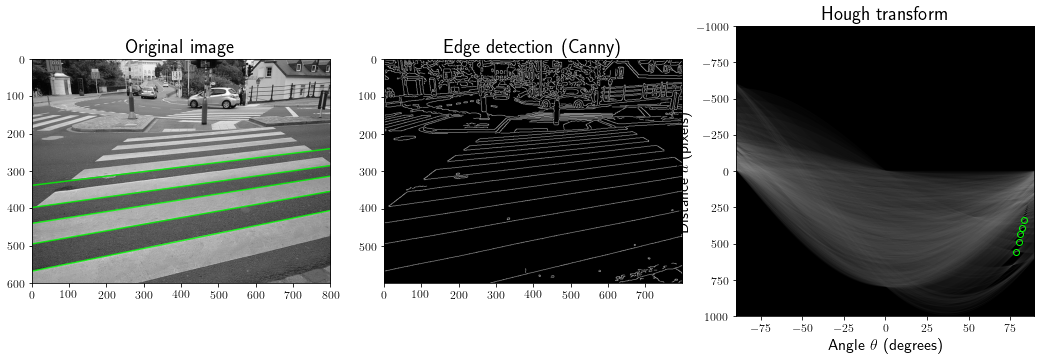

In [5]:
# Display
clr = 'lime'
# fs = 24
fig, axs = plt.subplots(1, 3, figsize=(15,5))
fig.tight_layout(pad=1.5)

# Image
img = io.imread("road-marking.jpg")
img = rgb2gray(img)
axs[0].imshow(img)
axs[0].set_title('Original image')

# Edge detection
edges = canny(img, sigma=1.5)
axs[1].imshow(edges)
axs[1].set_title('Edge detection (Canny)')

# Hough transform
theta = np.linspace(-np.pi/2, np.pi/2, 360, endpoint=False)
h, theta, d = hough_line(edges, theta=theta)
peaks, angles, dists = hough_line_peaks(h, theta, d, threshold=.1*h.max(), num_peaks=5)
axes = (np.rad2deg(theta[0]), np.rad2deg(theta[-1]), d[-1], d[0])
axs[2].imshow((1+h)**(.5), extent=axes, aspect="auto")
axs[2].plot(np.rad2deg(angles), dists, marker='o', markeredgecolor=clr, markerfacecolor="none", linestyle="none")
axs[2].set_title('Hough transform')
axs[2].set_xlabel('Angle $\\theta$ (degrees)')
axs[2].set_ylabel('Distance $d$ (pixels)')

# Lines
for _, angle, dist in zip(peaks, angles, dists):
    
    # Coordonnée de la ligne
    x0 = 0
    y0 = dist / np.sin(angle)
    x1 = img.shape[1]
    y1 = (dist - x1*np.cos(angle)) / np.sin(angle)
    
    # Tracé de la ligne
    axs[0].plot((x0, x1), (y0, y1), color=clr, alpha=.8)

axs[0].set_xlim(0,img.shape[1])
axs[0].set_ylim(img.shape[0],0)

plt.savefig('hough-example.svg', bbox_inches='tight')
plt.show()